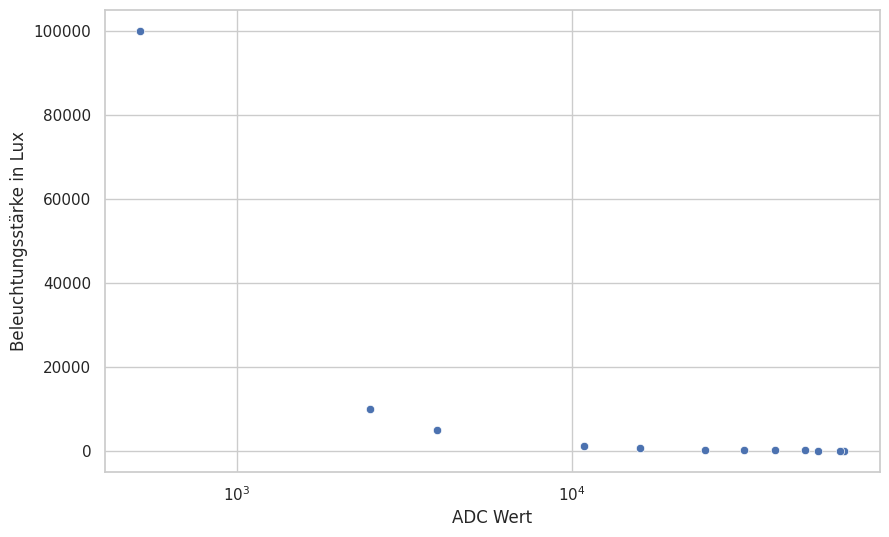

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame from your data
data = {
    'ADC': [65007, 63007, 54301, 49484, 40489, 32727, 24950, 15987, 10866, 3952, 2496, 512],
    'Lux': [0.1, 1, 10, 20, 50, 100, 200, 501, 1000, 5000, 10000, 100000]
}
df = pd.DataFrame(data)

# Create the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(y='Lux', x='ADC', data=df)

# Set the labels
plt.ylabel('Beleuchtungsstärke in Lux')
plt.xlabel('ADC Wert')

# Set x-axis to logarithmic scale
plt.xscale('log')

plt.show()

Hyperbelartiger Verlauf. $f(x)=\frac{1}{x-a}+b$ oder ähnliches könnte passen. Allerdings führt das im Vorliegenden Fall zu sehr kleinen $a$ und $b$, was im weiteren verlauf Probleme macht.

Alternativ können wir eine log-log-Transformation vornehmen und dann mit einem Linearen Zusammenhang arbeiten:

In [9]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Vorbereitung der Daten im Log-Raum
# Wir fitten log(Lux) als Funktion von log(ADC) oder umgekehrt.
# Hier: log10(Lux) = beta_1 * log10(ADC) + beta_0

x_log = np.log10(df['ADC']).values.reshape(-1, 1)
y_log = np.log10(df['Lux']).values

model = LinearRegression()
model.fit(x_log, y_log)

beta_1 = model.coef_[0]
beta_0 = model.intercept_
r_squared = model.score(x_log, y_log)

print(f"Gefittete Parameter im Log-Log-Raum:")
print(f"beta_1 (Steigung): {beta_1:.4f}")
print(f"beta_0 (Achsenabschnitt): {beta_0:.4f}")
print(f"Bestimmtheitsmaß R²: {r_squared:.4f}")

# Beispielhafte Mapping-Funktion basierend auf dem Fit
def map_log_fitted(z):
    return 10**(beta_0 + beta_1 * np.log10(z))

Gefittete Parameter im Log-Log-Raum:
beta_1 (Steigung): -2.3332
beta_0 (Achsenabschnitt): 11.9614
Bestimmtheitsmaß R²: 0.8260


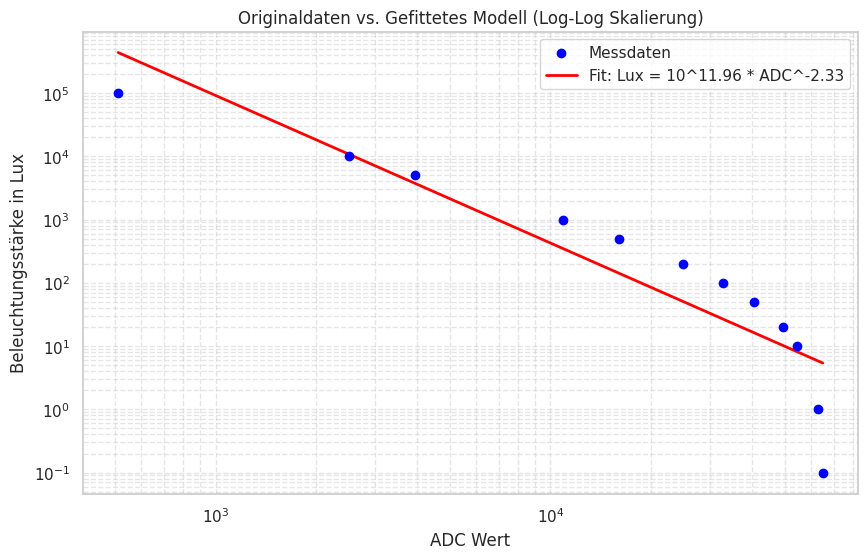

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Erzeuge x-Werte für die Kurve (ADC-Bereich)
x_fit = np.logspace(np.log10(df['ADC'].min()), np.log10(df['ADC'].max()), 100)
y_fit = map_log_fitted(x_fit)

plt.figure(figsize=(10, 6))

# Originaldaten
plt.scatter(df['ADC'], df['Lux'], color='blue', label='Messdaten', zorder=5)

# Gefittete Kurve
plt.plot(x_fit, y_fit, color='red', lw=2, label=f'Fit: Lux = 10^{beta_0:.2f} * ADC^{beta_1:.2f}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('ADC Wert')
plt.ylabel('Beleuchtungsstärke in Lux')
plt.title('Originaldaten vs. Gefittetes Modell (Log-Log Skalierung)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

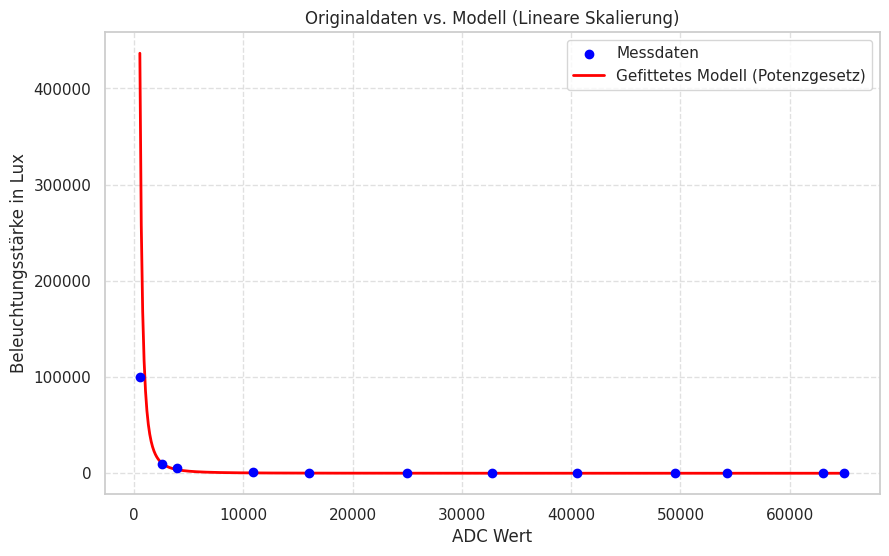

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Erzeuge x-Werte im linearen Bereich für eine glatte Kurve
x_lin = np.linspace(df['ADC'].min(), df['ADC'].max(), 500)
y_lin_fit = map_log_fitted(x_lin)

plt.figure(figsize=(10, 6))

# Originaldaten
plt.scatter(df['ADC'], df['Lux'], color='blue', label='Messdaten', zorder=5)

# Gefittete Kurve (Potenzfunktion)
plt.plot(x_lin, y_lin_fit, color='red', lw=2, label='Gefittetes Modell (Potenzgesetz)')

plt.xlabel('ADC Wert')
plt.ylabel('Beleuchtungsstärke in Lux')
plt.title('Originaldaten vs. Modell (Lineare Skalierung)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Erweiterung des Linearen Mappings:

```Python
def map_lin(z):
    E_max = 1
    E_min = 0
    z_max = 65535
    z_min = 0
    beta_0 = E_min
    beta_1 = (E_max - E_min) / (z_max - z_min)
    return beta_0 + beta_1 * z
```


In [14]:
import numpy as np

def map_log_log_lin(z):
    """
    Transformiert ADC-Werte in Lux-Werte basierend auf dem Log-Log-Fit:
    log10(Lux) = beta_1 * log10(ADC) + beta_0
    """
    # 1. Log-Transformation des Inputs
    log_z = np.log10(z)

    # 2. Lineares Mapping im Log-Raum (unter Verwendung der gefitteten Parameter)
    log_E = -2.3332 * log_z + 11.9614

    # 3. Rücktransformation (Exponentialfunktion zur Basis 10)
    return 10**log_E

# Test mit einem ADC-Wert
print(f"ADC 32727 wird gemappt auf: {map_log_log_lin(32727):.2f} Lux")

ADC 32727 wird gemappt auf: 26.74 Lux


Vergleiche mit unseren Messwerten:

ADC E
49484	20
40489	50
32727	100

Ist das Ergebnis nicht wirklich gut, aber für allesweitere Ausreichend.


In [17]:
import math

def map_log_log_lin(z):
    """
    Transformiert ADC-Werte in Lux-Werte basierend auf dem Log-Log-Fit:
    log10(Lux) = beta_1 * log10(ADC) + beta_0
    """
    # 1. Log-Transformation des Inputs
    log_z = math.log10(z)

    # 2. Lineares Mapping im Log-Raum (unter Verwendung der gefitteten Parameter)
    log_E = -2.3332 * log_z + 11.9614

    # 3. Rücktransformation (Exponentialfunktion zur Basis 10)
    return 10**log_E

# Test mit einem ADC-Wert
print(f"ADC 32727 wird gemappt auf: {map_log_log_lin(32727):.2f} Lux")

ADC 32727 wird gemappt auf: 26.74 Lux
